# DEF-D Fysieke Ontwerpopdracht 1 invul template

## Groepsgegevens en planning 

Aan het einde van deze ontwerpopdracht lever je als groep dit notebook gezamenlijk in via een pull request op Github en lever je een link naar dit pull request in op Brightspace. Zet jullie studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan. Werk in de juiste branch.

| Groep: XX     |  |
| :-------------|:-------------|
| Bob Villerius| 6483895 |
| Adam Echant Hamdioui | 6563031 |
| Erik van den Berg| 6328407 |

| Planning Groep: XX     |Tijdstip / Tijdspanne  |
|---|---|
| Mijlpaal 1: Criteria opgesteld | 12:00  |
| Mijlpaal 2: Eerste kalibratie meting gedaan| 14:30 |
| Pauze 1| grote pauze (1 uur) |
| Pauze 2| na eerste kalibratie (15-20 min) |

## *Opdracht 1*: Foto van alle schetsen.

Zet de foto in dezelfde map als dit notebook en verander hieronder de naam in de naam van de foto.

![Alt](IMG_2090.jpeg "analyse: ideeen")
![Alt](IMG_2091.jpeg "analyse: ideeen")

## *Opdracht 2*, MIJLPAAL, Leerdoel
Vul onderstaande tabel in en geef aan met welke sensor je verder gaat.** Laat dit aan je TA zien.** Als je TA druk is: ga wel ondertussen door met de volgende stap.

| Sensor | Toepassing | Criteria |
|:---|:---|:---|
|Lichtsensor | Lamp gaat aan bij bepaalde lichtsterkte | lantaarnpaal gaat uit als er meer dan 20 +/- 1 lux op valt. |
|Lichtsensor | Lamp gaat aan bij bepaalde lichtsterkte  | De meetrange vanaf 10 tot 2000 lux |
|Lichtsensor | Lamp gaat aan bij bepaalde lichtsterkte | Alleen het licht van de zon meten |
|Temperatuursensor | Temperatuur meten  | Temperatuur geven in Celius |
|Temperatuursensor | Temperatuur meten  | Elke 5 seconden een meting doen. |
|Temperatuursensor | Temperatuur meten  | Tussen de -10 en 40 graden Celius een onzekerheid van 1 graad Celius |
|Krachtsensor | Kracht om een deurbel in te drukken. | Deurbel mag pas afgaan wanneer er met 10 N op de knop gedrukt wordt.|
|Krachtsensor| Kracht om een deurbel in te drukken. | Het moet een knop zijn. |
|Krachtsensor | Kracht om een deurbel in te drukken. | De geluidssterkte moet harder zijn als de knop harder ingedrukt wordt. |

Groep 30 heeft gekozen voor de lichtsensor. 

## *Opdracht 3*: Foto van de schets van jouw meetopstelling in.
We meten met de arduino en de lichtsensor de bits die de lichtsensor geeft. Tegelijk meten we de lichtsterkte met Phyfox om te kaliberen. De metingen in het donker doen we in een doos.
 ![Alt](IMG_2092.jpg "schets student")

## *Opdracht 4*: Beantwoord de vragen

1. Welke variabelen ga je veranderen? 
2. Over welk bereik ga je deze variabelen veranderen?
3. Wat ga je allemaal meten?
4. Hoeveel metingen ga je doen?
5. Ga je met deze keuzes kunnen evalueren of jouw sensor geschikt is voor de gekozen toepassingen?

1. We gaan de lichtsterkte veranderen.
2. De lichtsterkte gaan we vanaf 0 tot 2000 lux
3. We meten de bits die de lichtsensor via de arduino geeft en we meten de licht die erop wordt geschenen met phyfox op een telefoon.
4. We gaan de 0 tot 2000 lux meten in 10 stappen van 2 lux per stap.
5. Ja hiermee kunnen we bepalen of de lamp aan zal gaan vanaf 20 +/- 1 lux (Schemering).

## *Opdracht 5*: Foto van jouw meetopstelling in. Leerdoel.
In de doos ligt een telefoon met Phyfox die de lichtsterkte meet in lux. In de doos licht ook de arduino + breadbord met lichtsensor die de lichtsterkte meet in bits. Om te meten gaan we vanaf een dichte doos een steeds meer open doen om de lichtsterkte te veranderen. Om Phyfox af te lezen bellen we met de telefoon in de doos. Die telefoon deelt zijn scherm.
 ![Alt](unnamed.jpg "meetopstelling student")

## *Opdracht 6*: Meten en fitten, Leerdoel

In [1]:
# Zet hier jouw data in een voor jou handig formaat
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
u_lux=1
u_bits=50

bits1=np.array([4, 48, 85, 124, 166, 240, 285, 310, 330, 357, 376, 390, 400, 412, 510, 598, 696])
lux1=np.array([0, 1, 2, 3,4,5,6, 7 , 8, 9, 10, 11, 12, 13, 20, 30, 39])

bits2=np.array([4, 25, 55, 78, 103, 130, 150, 180, 190, 210, 225, 246, 370, 407, 443, 510, 557, 595])
lux2=np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 20, 25, 30, 40, 50, 60])

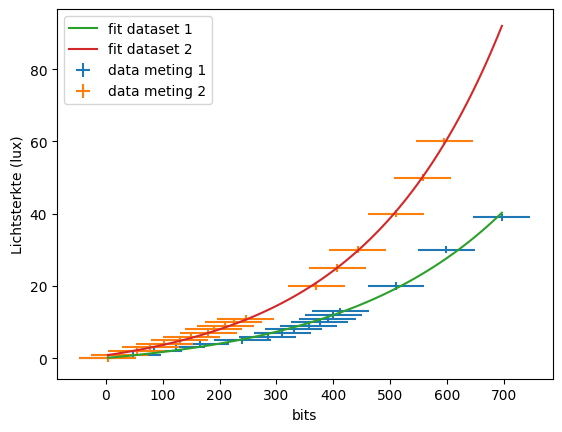

In [2]:
# Plot hier de meting en fit een lijn door de metingen.
# Maak gebruik van wat je geleerd hebt bij het practicum.
%matplotlib inline

def exp(x, a, b, c, d):
    return a * np.exp(b * (x-c))+d
val1, cov1 = curve_fit(exp, bits1, lux1, p0=(1, 0.001, 0, 0))
val2, cov2 = curve_fit(exp, bits2, lux2, p0=(1, 0.01, -1, 0))
bits_fit = np.linspace(min(bits1), max(bits1), 100)
plt.figure()
plt.errorbar(bits1,lux1, xerr=u_bits, yerr=u_lux, ls='none', label='data meting 1')
plt.errorbar(bits2,lux2, xerr=u_bits, yerr=u_lux, ls='none', label='data meting 2')
plt.plot(bits_fit, exp(bits_fit, *val1), label='fit dataset 1')
plt.plot(bits_fit, exp(bits_fit, *val2), label='fit dataset 2')
plt.xlabel('bits')
plt.ylabel('Lichtsterkte (lux)')
plt.savefig('lichtsterkte_tegen_bits.png')
plt.legend()
plt.show()

## *Opdracht 7*: Iteratie nodig?

We hebben niet genoeg data om onze vraag te beantwoorden. We gaan de metingen opnieuw uitvoeren.

## *Opdracht 8*: Conclusie, leerdoel
De sensor is niet bruikbaar voor ons doel.  Bij 20 +/- 1 lux zitten de waarde van de bits tussen de 320 en 580 bits. Door de grote schommelingen in bits zou de lantaarnpaal de hele tijd aan en uit gaan als de lichtsterkte rond die drempelwaarde zit. Hierdoor kan er geen goede drempelwaarde bepaald worden.

## *Opdracht 9*: Aantonen leerdoelen beheersing

Om aan te tonen dat je de leerdoelen beheerst, kopieer je hieronder alle cellen met 'leerdoel' in de titel. Zet zelf de cellen onder de goede kopjes. Mogelijk komt een cel bij meerdere leerdoelen terug.

### Leerdoel 1: Simpele circuits (RC-circuit, spanningsdelers met sensoren) ontwerpen en fabriceren.

## *Opdracht 5*: Foto van jouw meetopstelling in. Leerdoel.
In de doos ligt een telefoon met Phyfox die de lichtsterkte meet in lux. In de doos licht ook de arduino + breadbord met lichtsensor die de lichtsterkte meet in bits. Om te meten gaan we vanaf een dichte doos een steeds meer open doen om de lichtsterkte te veranderen. Om Phyfox af te lezen bellen we met de telefoon in de doos. Die telefoon deelt zijn scherm.
 ![Alt](unnamed.jpg "meetopstelling student")

### Leerdoel 2: Ontwerpeisen voor een opdracht SMART opstellen en vervolgens de ontwerpcyclus inrichten, rekening houdend met de randvoorwaarde van de opdracht.

## *Opdracht 2*, MIJLPAAL, Leerdoel
Vul onderstaande tabel in en geef aan met welke sensor je verder gaat.** Laat dit aan je TA zien.** Als je TA druk is: ga wel ondertussen door met de volgende stap.

| Sensor | Toepassing | Criteria |
|:---|:---|:---|
|Lichtsensor | Lamp gaat aan bij bepaalde lichtsterkte | lantaarnpaal gaat uit als er meer dan 20 +/- 1 lux op valt. |
|Lichtsensor | Lamp gaat aan bij bepaalde lichtsterkte  | De meetrange vanaf 10 tot 2000 lux |
|Lichtsensor | Lamp gaat aan bij bepaalde lichtsterkte | Alleen het licht van de zon meten |
|Temperatuursensor | Temperatuur meten  | Temperatuur geven in Celius |
|Temperatuursensor | Temperatuur meten  | Elke 5 seconden een meting doen. |
|Temperatuursensor | Temperatuur meten  | Tussen de -10 en 40 graden Celius een onzekerheid van 1 graad Celius |
|Krachtsensor | Kracht om een deurbel in te drukken. | Deurbel mag pas afgaan wanneer er met 10 N op de knop gedrukt wordt.|
|Krachtsensor| Kracht om een deurbel in te drukken. | Het moet een knop zijn. |
|Krachtsensor | Kracht om een deurbel in te drukken. | De geluidssterkte moet harder zijn als de knop harder ingedrukt wordt. |

Groep 30 heeft gekozen voor de lichtsensor. 

### Leerdoel 3: Voor een gegeven sensor & analoog-digitaal convertor en gegeven (of zelf gekozen) toepassing een kalibratie meting ontwerpen, inclusief het circuit om de sensor aan te sluiten op de analoog-digitaal convertor, de opstelling bouwen, en meetresultaten verwerken en concluderen of de combinatie van sensor en analoog-digitaal conversie geschikt is voor de toepassing.

Kopieer hier de cel(len) waaruit blijkt dat jullie leerdoel 3 beheersen.

## *Opdracht 8*: Conclusie, leerdoel
De sensor is niet bruikbaar voor ons doel.  Bij 20 +/- 1 lux zitten de waarde van de bits tussen de 320 en 580 bits. Door de grote schommelingen in bits zou de lantaarnpaal de hele tijd aan en uit gaan als de lichtsterkte rond die drempelwaarde zit. Hierdoor kan er geen goede drempelwaarde bepaald worden.

## *Opdracht 6*: Meten en fitten, Leerdoel

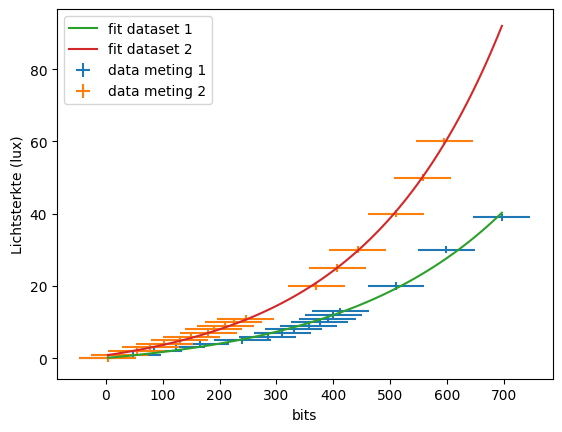

In [3]:
# Zet hier jouw data in een voor jou handig formaat
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
u_lux=1
u_bits=50

bits1=np.array([4, 48, 85, 124, 166, 240, 285, 310, 330, 357, 376, 390, 400, 412, 510, 598, 696])
lux1=np.array([0, 1, 2, 3,4,5,6, 7 , 8, 9, 10, 11, 12, 13, 20, 30, 39])

bits2=np.array([4, 25, 55, 78, 103, 130, 150, 180, 190, 210, 225, 246, 370, 407, 443, 510, 557, 595])
lux2=np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 20, 25, 30, 40, 50, 60])

# Plot hier de meting en fit een lijn door de metingen.
# Maak gebruik van wat je geleerd hebt bij het practicum.
%matplotlib inline

def exp(x, a, b, c, d):
    return a * np.exp(b * (x-c))+d
val1, cov1 = curve_fit(exp, bits1, lux1, p0=(1, 0.001, 0, 0))
val2, cov2 = curve_fit(exp, bits2, lux2, p0=(1, 0.01, -1, 0))
bits_fit = np.linspace(min(bits1), max(bits1), 100)
plt.figure()
plt.errorbar(bits1,lux1, xerr=u_bits, yerr=u_lux, ls='none', label='data meting 1')
plt.errorbar(bits2,lux2, xerr=u_bits, yerr=u_lux, ls='none', label='data meting 2')
plt.plot(bits_fit, exp(bits_fit, *val1), label='fit dataset 1')
plt.plot(bits_fit, exp(bits_fit, *val2), label='fit dataset 2')
plt.xlabel('bits')
plt.ylabel('Lichtsterkte (lux)')
plt.savefig('lichtsterkte_tegen_bits.png')
plt.legend()
plt.show()


## *Opdracht 5*: Foto van jouw meetopstelling in. Leerdoel.
In de doos ligt een telefoon met Phyfox die de lichtsterkte meet in lux. In de doos licht ook de arduino + breadbord met lichtsensor die de lichtsterkte meet in bits. Om te meten gaan we vanaf een dichte doos een steeds meer open doen om de lichtsterkte te veranderen. Om Phyfox af te lezen bellen we met de telefoon in de doos. Die telefoon deelt zijn scherm. 
 ![Alt](unnamed.jpg "meetopstelling student")